# Spatial Transcriptomics Analysis

## Setup Environment

- conda create -n kogo_stLENS
- conda activate kogo_stLENS
- conda install python=3.11 ipykernel  
-> select kernel : kogo_stLENS

In [1]:
# This is not necessary on Google Colab!
%conda install -c conda-forge cupy

Channels:
 - conda-forge
 - bioconda
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 24.3.0
    latest version: 25.5.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /home/khyeonmin/micromamba/envs/kogo_stLENS

  added / updated specs:
    - cupy


The following NEW packages will be INSTALLED:

  cuda-cccl_linux-64 conda-forge/noarch::cuda-cccl_linux-64-12.9.27-ha770c72_0 
  cuda-cudart-dev_l~ conda-forge/noarch::cuda-cudart-dev_linux-64-12.9.79-h3f2d84a_0 
  cuda-cudart-stati~ conda-forge/noarch::cuda-cudart-static_linux-64-12.9.79-h3f2d84a_0 
  cuda-cudart_linux~ conda-forge/noarch::cuda-cudart_linux-64-12.9.79-h3f2d84a_0 
  cuda-nvrtc         conda-forge/linux-64::cuda-nvrtc-12.9.86-h5888daf_0 
  cuda-version       conda-forge/noarch::cuda-version-12.9-h4f385c5_3 
  cupy               conda-forge/linux-64::cupy-13.5.1-py311h72da3fd_1 

In [2]:
%pip install git+https://github.com/pnucolab/stLENS

  Cloning https://github.com/pnucolab/stLENS to /tmp/pip-req-build-cvdczct9
  Running command git clone --filter=blob:none --quiet https://github.com/pnucolab/stLENS /tmp/pip-req-build-cvdczct9
  Resolved https://github.com/pnucolab/stLENS to commit 05aa21d39293f3339911f23d7e4529850ef7557c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached scanpy-1.11.3-py3-none-any.whl.metadata (9.0 kB)
  Using cached pandas-2.3.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (91 kB)
  Using cached scipy-1.15.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached zarr-2.18.7-py3-none-any.whl.metadata (5.8 kB)
  Using cached matplotlib-3.10.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached dask-2025.7.

In [3]:
%pip install spatialdata-io spatialdata-plot

  Using cached spatialdata_io-0.2.0-py3-none-any.whl.metadata (9.4 kB)
  Using cached spatialdata_plot-0.2.10-py3-none-any.whl.metadata (7.5 kB)
  Using cached dask_image-2024.5.3-py3-none-any.whl.metadata (2.8 kB)
  Using cached imagecodecs-2025.3.30-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached ome_types-0.6.1-py3-none-any.whl.metadata (11 kB)
  Using cached pyarrow-21.0.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (3.3 kB)
  Using cached readfcs-2.0.1-py2.py3-none-any.whl.metadata (1.8 kB)
  Using cached scikit_image-0.25.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (14 kB)
  Using cached spatialdata-0.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached tifffile-2025.6.11-py3-none-any.whl.metadata (32 kB)
  Using cached matplotlib_scalebar-0.9.0-py3-none-any.whl.metadata (18 kB)
  Using cached dask-2024.11.2-py3-none-any.whl.metadata (3.7 kB)
  Using cached geopandas-1.1.1-py3-none-any.whl.metadata (2.3 kB)
 

## Visium HD

### Load data

In [4]:
import spatialdata as sd
sdata = sd.read_zarr("visiumhd_sdata_cropped.zarr")
sdata

/home/khyeonmin/micromamba/envs/kogo_stLENS/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/khyeonmin/micromamba/envs/kogo_stLENS/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
version mismatch: detected: RasterFormatV02, requested: FormatV04
/home/khyeonmin/micromamba/envs/kogo_stLENS/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_onl

SpatialData object, with associated Zarr store: /home/khyeonmin/projects/2025_kogo/tutorial/spatial-omics-tutorials/visiumhd_sdata_cropped.zarr
├── Images
│     ├── 'Visium_HD_Human_Colon_Cancer_P1_hires_image': DataArray[cyx] (3, 843, 844)
│     └── 'Visium_HD_Human_Colon_Cancer_P1_lowres_image': DataArray[cyx] (3, 84, 84)
├── Shapes
│     ├── 'Visium_HD_Human_Colon_Cancer_P1_square_002um': GeoDataFrame shape: (1849989, 1) (2D shapes)
│     ├── 'Visium_HD_Human_Colon_Cancer_P1_square_008um': GeoDataFrame shape: (116132, 1) (2D shapes)
│     └── 'Visium_HD_Human_Colon_Cancer_P1_square_016um': GeoDataFrame shape: (29232, 1) (2D shapes)
└── Tables
      ├── 'square_002um': AnnData (1849989, 18085)
      ├── 'square_008um': AnnData (116132, 18085)
      └── 'square_016um': AnnData (29232, 18085)
with coordinate systems:
    ▸ 'Visium_HD_Human_Colon_Cancer_P1', with elements:
        Visium_HD_Human_Colon_Cancer_P1_hires_image (Images), Visium_HD_Human_Colon_Cancer_P1_lowres_image (Images)

In [5]:
import scanpy as sc
adata = sdata.tables['square_008um']

/tmp/ipykernel_3557669/3159902038.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='DeconvolutionLabel1', spot_size=100)


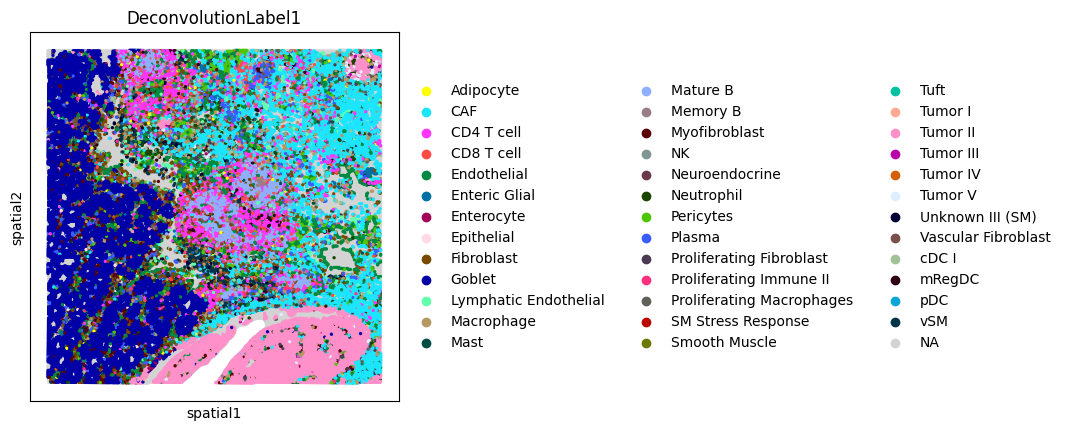

In [ ]:
sc.pl.spatial(adata, color='DeconvolutionLabel1', spot_size=100)

### Quality Control & Normalization

Filtering with stLENS:

In [7]:
from stLENS import stLENS
stlens = stLENS()

/home/khyeonmin/micromamba/envs/kogo_stLENS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
stlens.filter_cells_and_genes(adata, mito_percent=20)

/home/khyeonmin/micromamba/envs/kogo_stLENS/lib/python3.11/site-packages/stLENS/stLENS.py:187: RuntimeWarning: invalid value encountered in divide
  mito_ratio = np.array(mito_sum / total_sum).flatten()


After filtering >> shape: (26966, 15608)


Optional: Filtering with Scanpy:

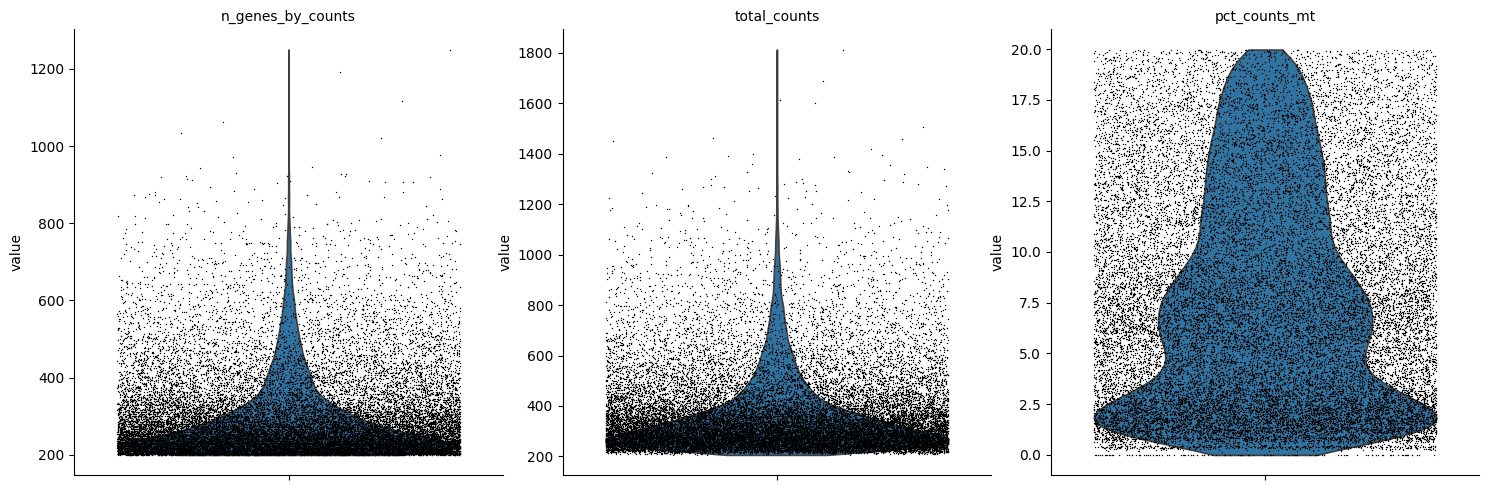

In [92]:
import scanpy as sc

adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], inplace=False, log1p=True
)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [ ]:
adata.layers["counts"] = adata.X.copy()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=15)
adata = adata[adata.obs.pct_counts_mt < 20, :]

Visualize filtered adata

/tmp/ipykernel_3208089/3159902038.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='DeconvolutionLabel1', spot_size=100)


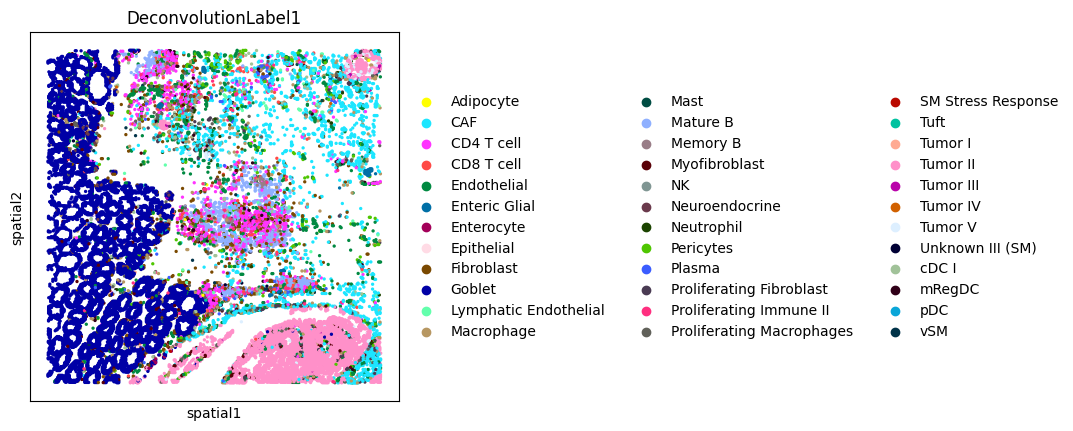

In [9]:
sc.pl.spatial(adata, color='DeconvolutionLabel1', spot_size=100)

### PCA

/home/khyeonmin/micromamba/envs/kogo_stLENS/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


sparsity_th: 0.032987193742481255


/home/khyeonmin/micromamba/envs/kogo_stLENS/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/khyeonmin/micromamba/envs/kogo_stLENS/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


Min(corr): 0.038541316986083984, sparsity: 0.999


/home/khyeonmin/micromamba/envs/kogo_stLENS/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


...

Min(corr): 0.030786048620939255, sparsity: 0.995


/home/khyeonmin/micromamba/envs/kogo_stLENS/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


Min(corr): 0.030168496072292328, sparsity: 0.994


/home/khyeonmin/micromamba/envs/kogo_stLENS/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


Min(corr): 0.029973354190587997, sparsity: 0.993
Max interactions exceeded!
lambda_c: 5.004815
Number of signal: 80


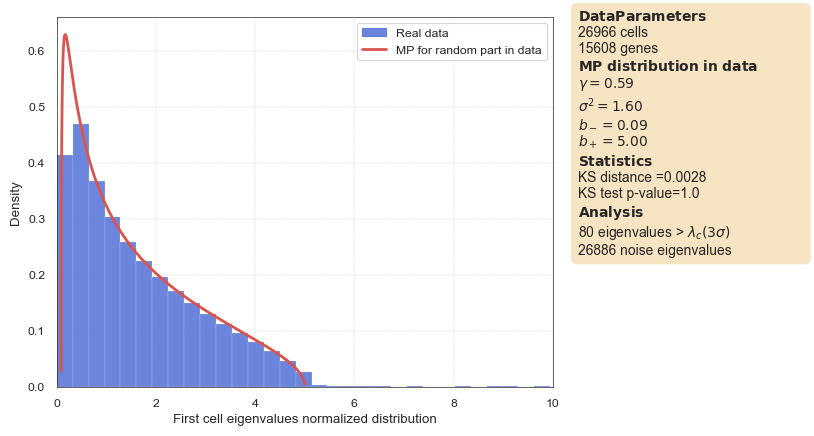

  0%|          | 0/20 [00:00<?, ?it/s]/home/khyeonmin/micromamba/envs/kogo_stLENS/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
  5%|▌         | 1/20 [00:18<05:45, 18.18s/it]/home/khyeonmin/micromamba/envs/kogo_stLENS/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
 10%|█         | 2/20 [00:35<05:18, 17.68s/it]/home/khyeonmin/micromamba/envs/kogo_stLENS/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
 15%|█▌        | 3/20 [00:53<04:59, 17.62s/it]/home/khyeonmin/micromamba/envs/kogo_stLENS/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill

number of filtered signals: 25


25

In [9]:
stlens.find_optimal_pc(adata, plot_mp=True)

In [10]:
n_comps = adata.uns['stlens']['optimal_pc_count']
print("Optimal number of PCs:", n_comps)

Optimal number of PCs: 25


In [11]:
# PCA transformation using stLENS’s pca function
# Note that the PCA result is l2 normalized - thus all the downstream analyses should use cosine distance as the metric.
stlens.pca(adata)

In [12]:
adata.obsm['X_pca_stlens']

array([[ 0.00954213,  0.00309129, -0.00390751, ..., -0.00327145,
        -0.09188442,  0.03998631],
       [-0.00620765,  0.00891101, -0.0041188 , ...,  0.00988002,
        -0.04318553,  0.01984949],
       [-0.02044461, -0.01001313,  0.01125323, ...,  0.08908678,
         0.00093755, -0.05465166],
       ...,
       [ 0.0108533 , -0.00098609, -0.01009347, ...,  0.00324986,
        -0.03665039,  0.0176645 ],
       [ 0.00140312,  0.01115828, -0.01595249, ..., -0.04584608,
         0.04861146, -0.09748109],
       [-0.00068422,  0.00343749,  0.01039548, ...,  0.02194603,
        -0.04136275,  0.00573214]], shape=(26966, 25))

Find clusters using stLENS PCA result

In [ ]:
!pip3 install igraph

  Using cached igraph-0.11.9-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.4 kB)
  Using cached texttable-1.7.0-py2.py3-none-any.whl.metadata (9.8 kB)
Using cached igraph-0.11.9-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.4 MB)
Using cached texttable-1.7.0-py2.py3-none-any.whl (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [igraph]2m1/2 [igraph]


In [15]:
sc.pp.neighbors(adata, use_rep='X_pca_stlens', metric='cosine')
sc.tl.leiden(adata, flavor='igraph', n_iterations=2)

/tmp/ipykernel_3557669/2213031558.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='leiden', spot_size=100)


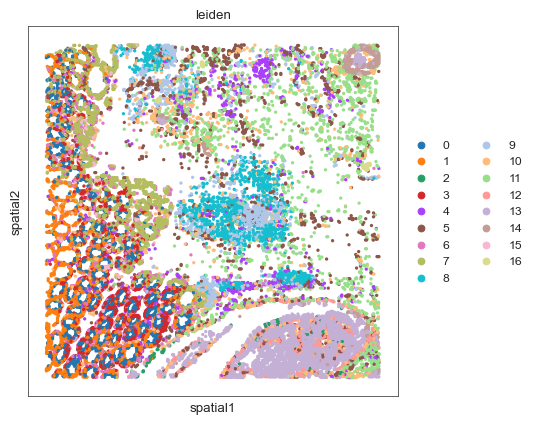

In [16]:
sc.pl.spatial(adata, color='leiden', spot_size=100)

Find clusters using Scanpy default

In [17]:
# You can also use Scanpy’s PCA function with the optimal number of principal components determined by stLENS.
sc.pp.pca(adata)
sc.pp.neighbors(adata, use_rep='X_pca')
sc.tl.leiden(adata, key_added='leiden_scanpy', flavor='igraph', n_iterations=2)

/tmp/ipykernel_3557669/2040562915.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='leiden_scanpy', spot_size=100)


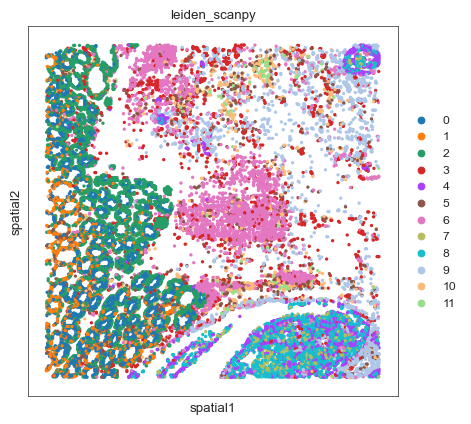

In [18]:
sc.pl.spatial(adata, color='leiden_scanpy', spot_size=100)

Comparing the clustering results with the ground truth

In [19]:
# find cluster centroids
import numpy as np
from scipy.spatial import distance
def find_cluster_centroids(adata, cluster_key):
    centroids = []
    for cluster in adata.obs[cluster_key].cat.categories:
        cluster_cells = adata[adata.obs[cluster_key] == cluster]
        centroid = np.array(np.mean(np.log1p(cluster_cells.X), axis=0)).flatten()
        centroids.append(centroid)
    return np.array(centroids)

centroids_gt = find_cluster_centroids(adata, 'DeconvolutionLabel1')
centroids_stlens = find_cluster_centroids(adata, 'leiden')
centroids_scanpy = find_cluster_centroids(adata, 'leiden_scanpy')

distances_stlens = distance.cdist(
    centroids_stlens, 
    centroids_gt,
    metric='correlation'
)
distances_scanpy = distance.cdist(
    centroids_scanpy,
    centroids_gt,
    metric='correlation'
)

closest_stlens = np.argmin(distances_stlens, axis=1)
closest_scanpy = np.argmin(distances_scanpy, axis=1)

adata.uns['leiden_colors'] = adata.uns['DeconvolutionLabel1_colors'][closest_stlens]
adata.uns['leiden_scanpy_colors'] = adata.uns['DeconvolutionLabel1_colors'][closest_scanpy]

In [20]:
print("Number of unique clusters found using stLENS:", len(set(closest_stlens)))
print("Number of unique clusters found using Scanpy:", len(set(closest_scanpy)))

Number of unique clusters found using stLENS: 11
Number of unique clusters found using Scanpy: 7


/tmp/ipykernel_3557669/85957765.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


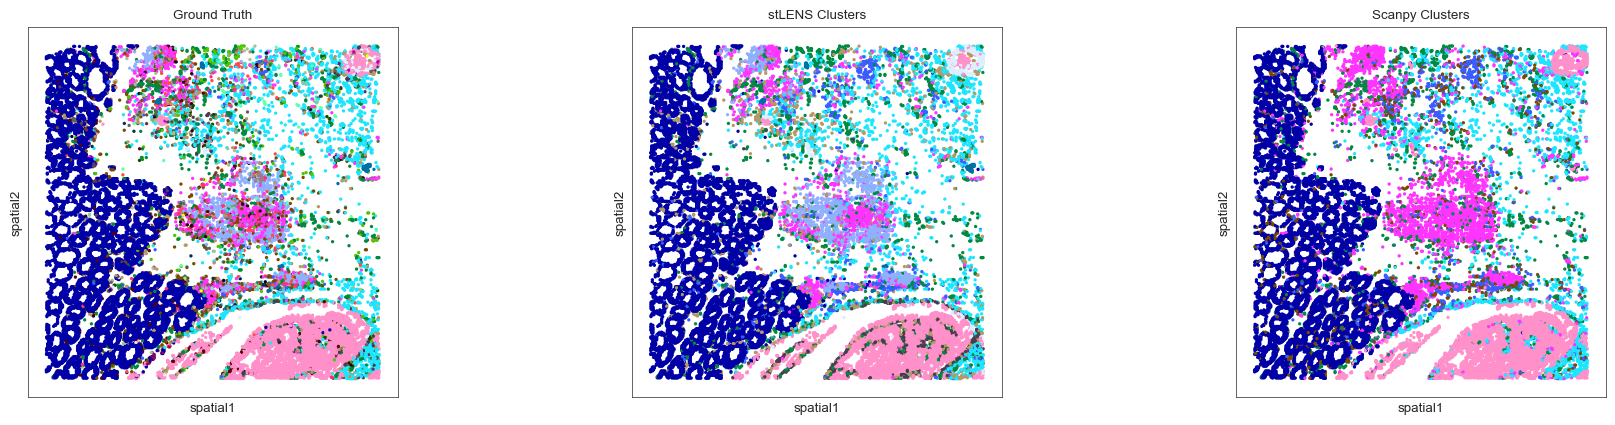

In [21]:
sc.pl.spatial(
    adata, 
    color=['DeconvolutionLabel1', 'leiden', 'leiden_scanpy'],
    spot_size=100,
    title=['Ground Truth', 'stLENS Clusters', 'Scanpy Clusters'],
    legend_loc='none'
)